Loading GTFS feed...
Busiest service date: (datetime.date(2026, 4, 30), frozenset({'3197', '3909', '3282', '2663', '512', '3937', '4676', '4692', '2734', '5223', '3456', '2327', '3903', '4155', '3455', '1817', '4400', '1082', '2185', '4180', '93', '442', '4225', '2693', '1254', '4108', '1951', '3338', '1816', '4274', '5306', '1132', '246', '1499', '2909', '1160', '3502', '514', '5266', '2574', '1401', '2228', '430', '2841', '2708', '2379', '3137', '4156', '1755', '4657', '4483', '4650', '991', '636', '357', '343', '5011', '9', '631', '1800', '2607', '2255', '3814', '3332', '618', '2160', '537', '446', '911', '3303', '1170', '2380', '4699', '3881', '2391', '1516', '4813', '1821', '564', '820', '2871', '4232', '2728', '3285', '2497', '480', '3264', '1676', '3785', '3546', '1780', '885', '5275', '5172', '1072', '3990', '1991', '1790', '3636', '3822', '2419', '616', '1245', '1317', '2616', '3603', '1843', '2919', '4208', '5198', '3810', '4595', '1689', '3616', '2352', '3843', '5194', '4914

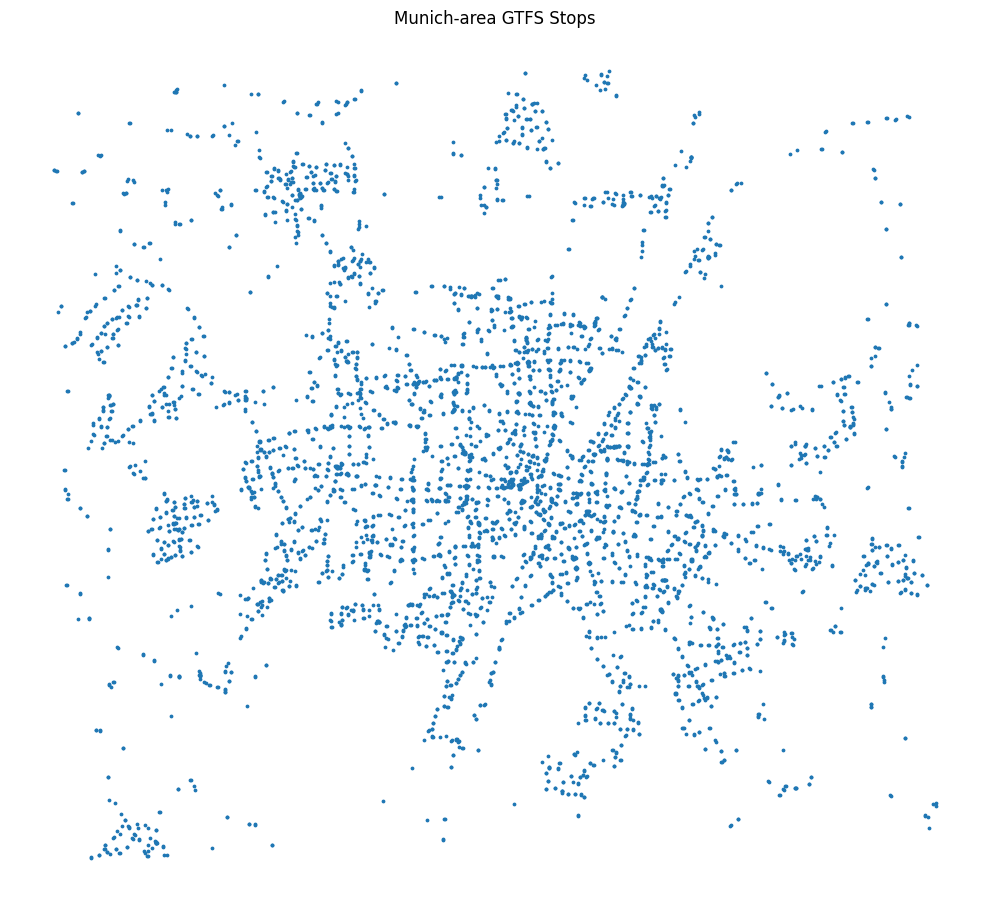


OSM graph downloaded.
Number of nodes: 14036
Number of edges: 36326


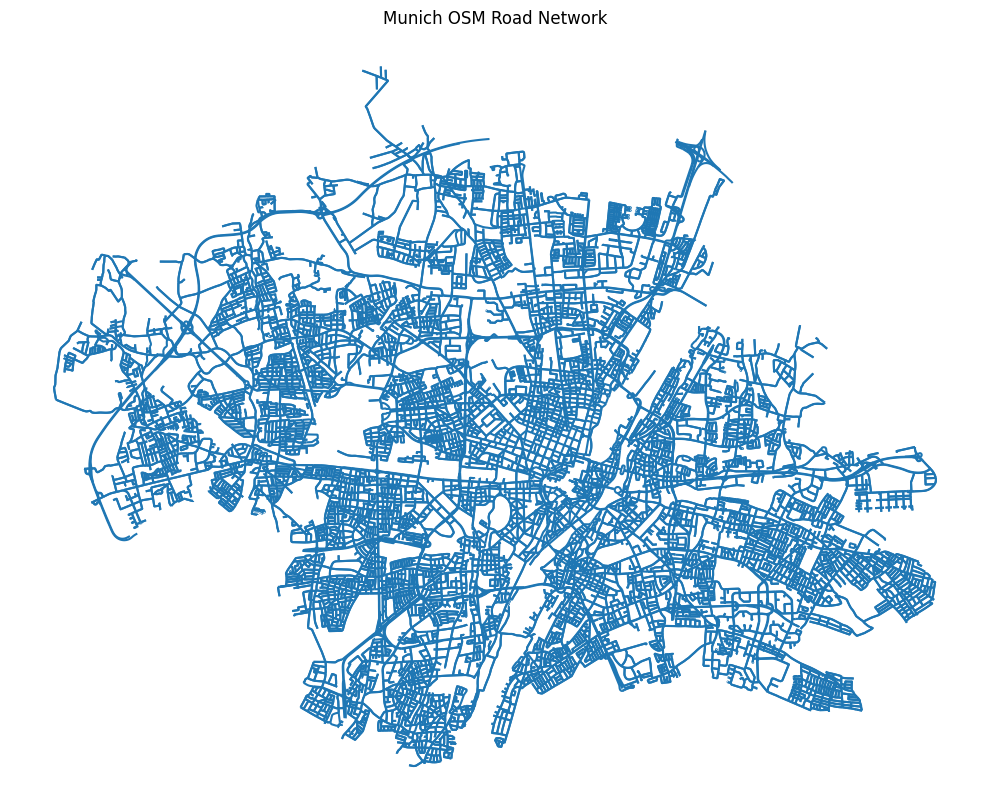

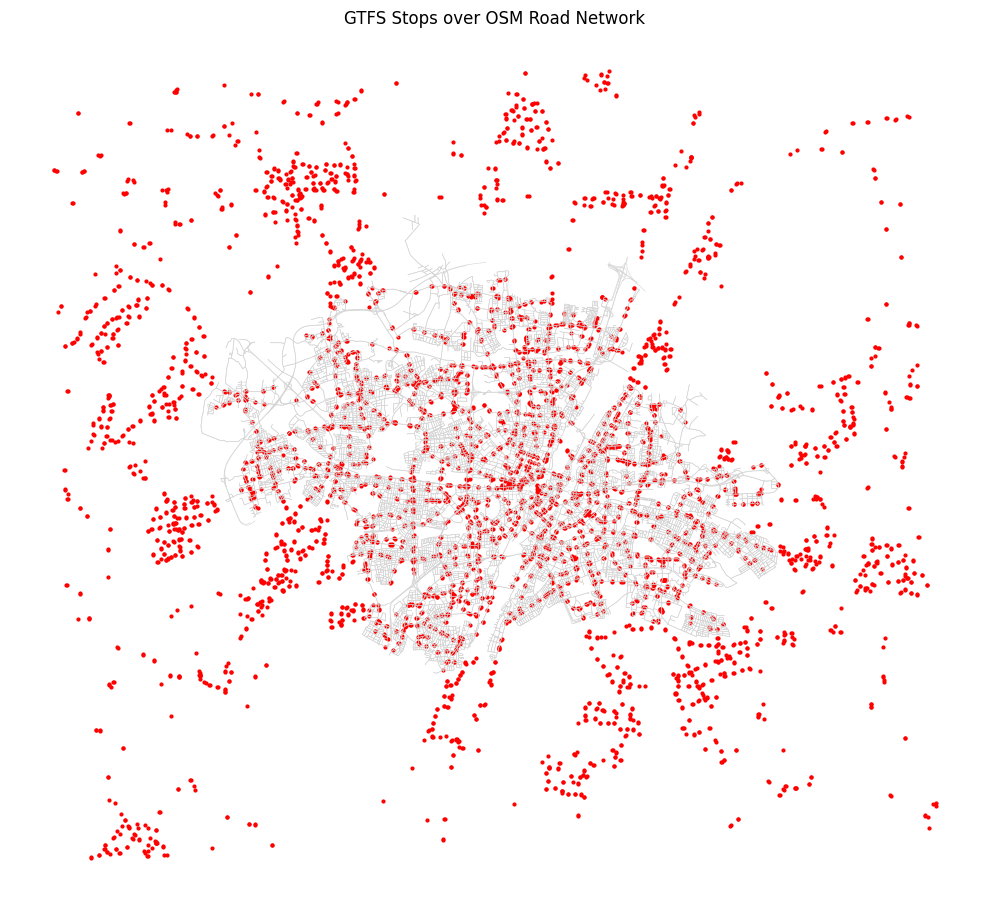


Snapping GTFS stops to nearest OSM nodes...

Computing graph metrics...
Graph metrics computed.


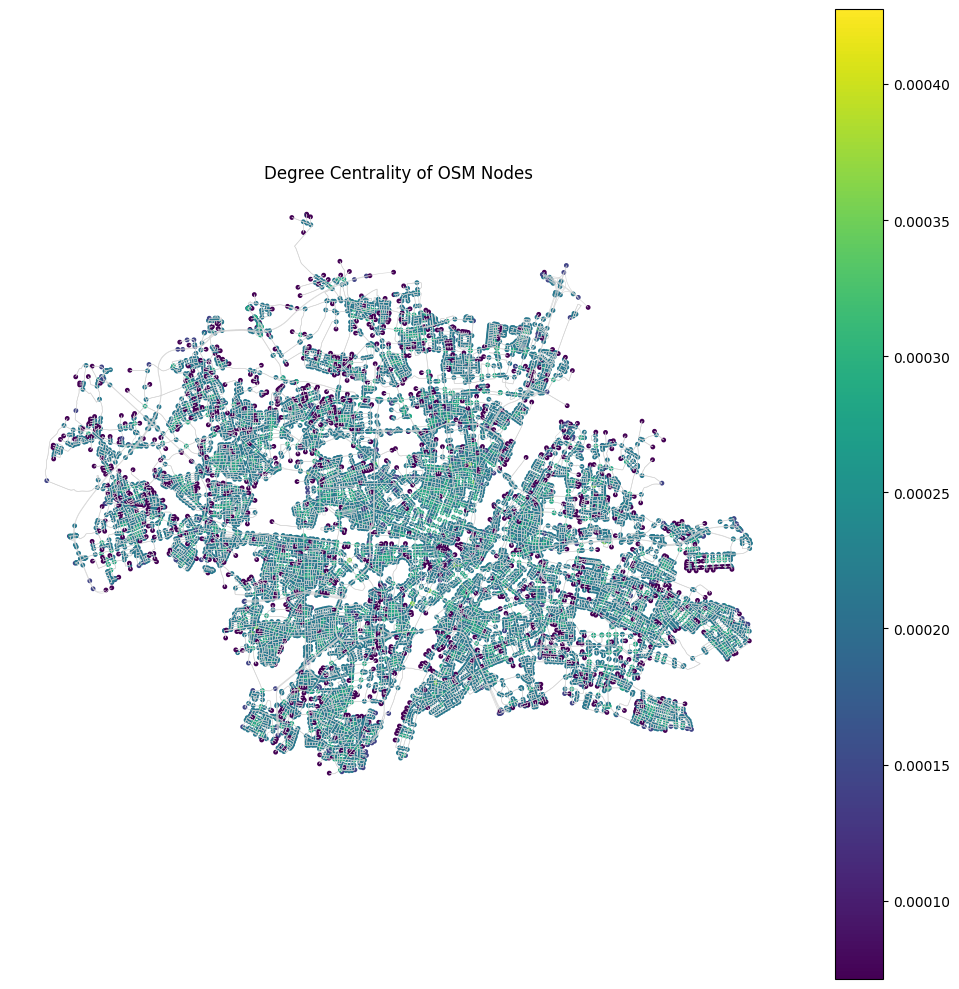

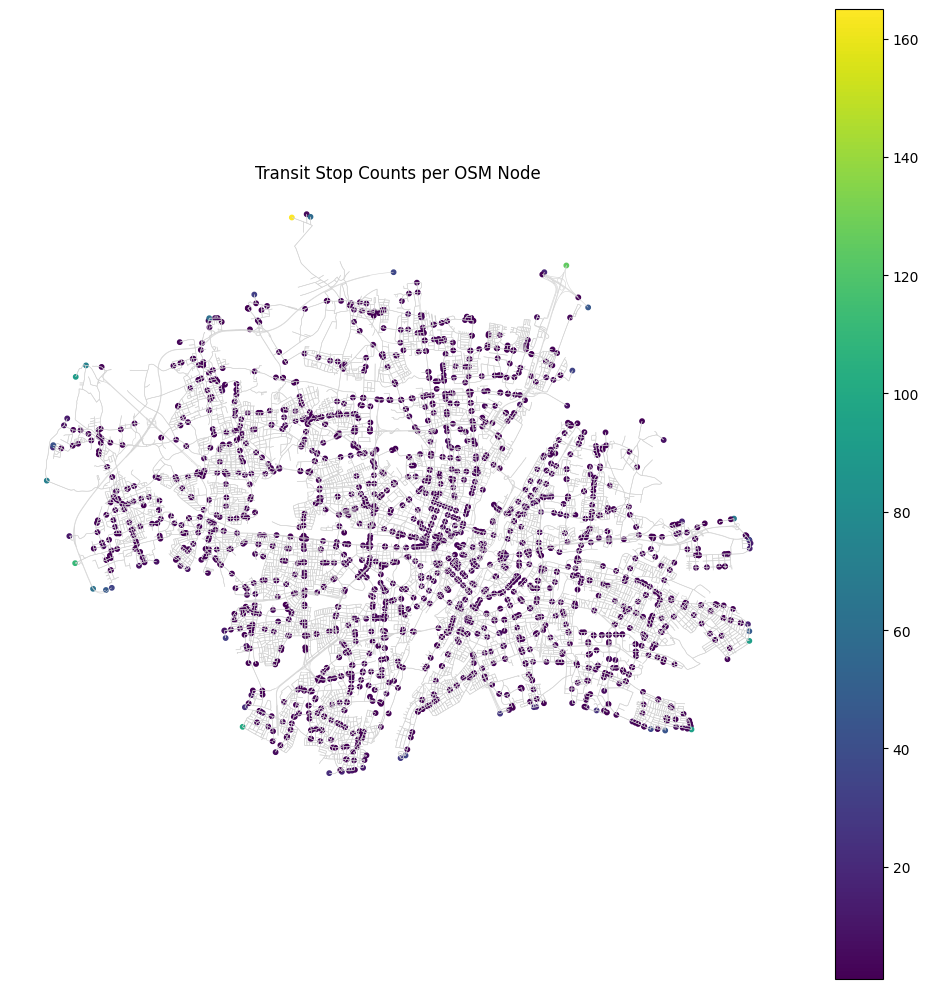


Saving processed files...

Done.
                   metric                                              value
0            service_date  (datetime.date(2026, 4, 30), frozenset({'3197'...
1            munich_stops                                               5069
2       munich_stop_times                                             575219
3            munich_trips                                              32840
4           munich_routes                                                467
5               osm_nodes                                              14036
6               osm_edges                                              36326
7  mean_degree_centrality                                           0.000214
8    mean_gtfs_stop_count                                           0.361143
9        mean_node_degree                                            2.99772

Files saved in:
../data/processed/
../outputs/maps/
../outputs/tables/


In [2]:
# ============================================================
# Spatial Network Analysis of Munich's Public Transit
# ============================================================

import os
import osmnx as ox
import geopandas as gpd
import pandas as pd
import networkx as nx
import partridge as ptg
import matplotlib.pyplot as plt

# -----------------------------
# Configuration
# -----------------------------
GTFS_PATH = "../data/raw/gtfs.zip"
PLACE = "Munich, Germany"
TARGET_CRS = "EPSG:32632"

# Rough Munich bounding box
MIN_LAT = 48.00
MAX_LAT = 48.30
MIN_LON = 11.30
MAX_LON = 11.80

# -----------------------------
# Utility Functions
# -----------------------------
def create_project_folders():
    os.makedirs("../data/raw", exist_ok=True)
    os.makedirs("../data/processed", exist_ok=True)
    os.makedirs("../outputs/maps", exist_ok=True)
    os.makedirs("../outputs/tables", exist_ok=True)

def check_gtfs_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"GTFS file not found: {path}")

def load_gtfs_feed(gtfs_path):
    print("Loading GTFS feed...")
    service_date = ptg.read_busiest_date(gtfs_path)
    print("Busiest service date:", service_date)

    view = {"trips.txt": {"service_id": service_date}}
    feed = ptg.load_feed(gtfs_path, view)

    print("\nGTFS feed loaded successfully.")
    print("Stops:", len(feed.stops))
    print("Routes:", len(feed.routes))
    print("Trips:", len(feed.trips))
    print("Stop times:", len(feed.stop_times))

    return service_date, feed

def filter_stops_by_bbox(stops, min_lat, max_lat, min_lon, max_lon):
    filtered = stops[
        (stops["stop_lat"] >= min_lat) &
        (stops["stop_lat"] <= max_lat) &
        (stops["stop_lon"] >= min_lon) &
        (stops["stop_lon"] <= max_lon)
    ].copy()

    if len(filtered) == 0:
        raise ValueError("No stops found in bounding box. Please adjust the coordinates or check the GTFS feed.")

    return filtered

def filter_gtfs_to_region(feed, filtered_stops):
    print("\nFiltering GTFS tables for selected region...")

    stop_ids = set(filtered_stops["stop_id"])

    filtered_stop_times = feed.stop_times[
        feed.stop_times["stop_id"].isin(stop_ids)
    ].copy()

    trip_ids = set(filtered_stop_times["trip_id"])

    filtered_trips = feed.trips[
        feed.trips["trip_id"].isin(trip_ids)
    ].copy()

    route_ids = set(filtered_trips["route_id"])

    filtered_routes = feed.routes[
        feed.routes["route_id"].isin(route_ids)
    ].copy()

    filtered_shapes = None
    if hasattr(feed, "shapes") and "shape_id" in filtered_trips.columns:
        shape_ids = set(filtered_trips["shape_id"].dropna())
        if len(shape_ids) > 0:
            filtered_shapes = feed.shapes[
                feed.shapes["shape_id"].isin(shape_ids)
            ].copy()

    print("Filtered stops:", len(filtered_stops))
    print("Filtered stop_times:", len(filtered_stop_times))
    print("Filtered trips:", len(filtered_trips))
    print("Filtered routes:", len(filtered_routes))

    if filtered_shapes is not None:
        print("Filtered shapes:", len(filtered_shapes))

    return filtered_stop_times, filtered_trips, filtered_routes, filtered_shapes

def stops_to_gdf(stops_df, target_crs):
    return gpd.GeoDataFrame(
        stops_df,
        geometry=gpd.points_from_xy(stops_df["stop_lon"], stops_df["stop_lat"]),
        crs="EPSG:4326"
    ).to_crs(target_crs)

def plot_gdf(gdf, title, path, edge_gdf=None, point_color=None, point_size=3):
    fig, ax = plt.subplots(figsize=(10, 10))

    if edge_gdf is not None:
        edge_gdf.plot(ax=ax, linewidth=0.4, color="lightgray")

    if point_color:
        gdf.plot(ax=ax, markersize=point_size, color=point_color)
    else:
        gdf.plot(ax=ax, markersize=point_size)

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()

def download_osm_network(place, target_crs):
    print("\nDownloading OSM road network...")
    G = ox.graph_from_place(place, network_type="drive", simplify=True)
    G_proj = ox.project_graph(G, to_crs=target_crs)

    print("OSM graph downloaded.")
    print("Number of nodes:", len(G_proj.nodes))
    print("Number of edges:", len(G_proj.edges))

    return G_proj

def graph_to_projected_gdfs(G_proj, target_crs):
    nodes, edges = ox.graph_to_gdfs(G_proj)
    nodes = nodes.to_crs(target_crs)
    edges = edges.to_crs(target_crs)
    return nodes, edges

def snap_stops_to_nearest_nodes(G_proj, stops_gdf):
    print("\nSnapping GTFS stops to nearest OSM nodes...")
    nearest_node_ids = ox.distance.nearest_nodes(
        G_proj,
        X=stops_gdf.geometry.x.to_numpy(),
        Y=stops_gdf.geometry.y.to_numpy()
    )
    stops_gdf = stops_gdf.copy()
    stops_gdf["nearest_node"] = nearest_node_ids
    return stops_gdf

def compute_graph_metrics(G_proj, nodes_gdf, stops_gdf):
    print("\nComputing graph metrics...")

    G_u = ox.convert.to_undirected(G_proj)
    largest_cc_nodes = max(nx.connected_components(G_u), key=len)
    G_cc = G_u.subgraph(largest_cc_nodes).copy()

    degree_centrality = nx.degree_centrality(G_cc)
    node_degree = dict(G_cc.degree())

    stop_counts = stops_gdf.groupby("nearest_node").size().rename("gtfs_stop_count")

    nodes_gdf = nodes_gdf.copy()
    nodes_gdf = nodes_gdf.join(stop_counts, how="left")
    nodes_gdf["gtfs_stop_count"] = nodes_gdf["gtfs_stop_count"].fillna(0).astype(int)
    nodes_gdf["degree_centrality"] = nodes_gdf.index.map(degree_centrality).fillna(0.0)
    nodes_gdf["node_degree"] = nodes_gdf.index.map(node_degree).fillna(0).astype(int)

    print("Graph metrics computed.")
    return nodes_gdf

def plot_metric_map(edges_gdf, nodes_gdf, column, title, path, markersize=6):
    fig, ax = plt.subplots(figsize=(10, 10))
    edges_gdf.plot(ax=ax, linewidth=0.4, color="lightgray")
    nodes_gdf.plot(ax=ax, column=column, markersize=markersize, legend=True)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()

def save_outputs(nodes_gdf, edges_gdf, stops_gdf, stop_times, trips, routes, shapes, service_date):
    print("\nSaving processed files...")

    nodes_gdf.reset_index().to_csv("../data/processed/munich_osm_nodes_metrics.csv", index=False)
    edges_gdf.reset_index().to_csv("../data/processed/munich_osm_edges.csv", index=False)
    stops_gdf.drop(columns="geometry").to_csv("../data/processed/munich_gtfs_stops_with_nearest_node.csv", index=False)
    stop_times.to_csv("../data/processed/munich_stop_times.csv", index=False)
    trips.to_csv("../data/processed/munich_trips.csv", index=False)
    routes.to_csv("../data/processed/munich_routes.csv", index=False)

    if shapes is not None:
        shapes.to_csv("../data/processed/munich_shapes.csv", index=False)

    summary = pd.DataFrame({
        "metric": [
            "service_date",
            "munich_stops",
            "munich_stop_times",
            "munich_trips",
            "munich_routes",
            "osm_nodes",
            "osm_edges",
            "mean_degree_centrality",
            "mean_gtfs_stop_count",
            "mean_node_degree"
        ],
        "value": [
            str(service_date),
            len(stops_gdf),
            len(stop_times),
            len(trips),
            len(routes),
            len(nodes_gdf),
            len(edges_gdf),
            nodes_gdf["degree_centrality"].mean(),
            nodes_gdf["gtfs_stop_count"].mean(),
            nodes_gdf["node_degree"].mean()
        ]
    })

    summary.to_csv("../outputs/tables/network_summary.csv", index=False)

    print("\nDone.")
    print(summary)
    print("\nFiles saved in:")
    print("../data/processed/")
    print("../outputs/maps/")
    print("../outputs/tables/")

# -----------------------------
# Main Workflow
# -----------------------------
create_project_folders()
check_gtfs_file(GTFS_PATH)

service_date, feed = load_gtfs_feed(GTFS_PATH)

munich_stops = filter_stops_by_bbox(
    feed.stops,
    MIN_LAT, MAX_LAT,
    MIN_LON, MAX_LON
)

munich_stop_times, munich_trips, munich_routes, munich_shapes = filter_gtfs_to_region(feed, munich_stops)

munich_stops_gdf = stops_to_gdf(munich_stops, TARGET_CRS)

plot_gdf(
    munich_stops_gdf,
    title="Munich-area GTFS Stops",
    path="../outputs/maps/munich_gtfs_stops.png"
)

G_proj = download_osm_network(PLACE, TARGET_CRS)
nodes_proj, edges_proj = graph_to_projected_gdfs(G_proj, TARGET_CRS)

plot_gdf(
    edges_proj,
    title="Munich OSM Road Network",
    path="../outputs/maps/munich_osm_network.png"
)

plot_gdf(
    munich_stops_gdf,
    title="GTFS Stops over OSM Road Network",
    path="../outputs/maps/munich_stops_over_network.png",
    edge_gdf=edges_proj,
    point_color="red",
    point_size=4
)

munich_stops_gdf = snap_stops_to_nearest_nodes(G_proj, munich_stops_gdf)

nodes_proj = compute_graph_metrics(G_proj, nodes_proj, munich_stops_gdf)

plot_metric_map(
    edges_proj,
    nodes_proj,
    column="degree_centrality",
    title="Degree Centrality of OSM Nodes",
    path="../outputs/maps/degree_centrality.png"
)

plot_metric_map(
    edges_proj,
    nodes_proj[nodes_proj["gtfs_stop_count"] > 0],
    column="gtfs_stop_count",
    title="Transit Stop Counts per OSM Node",
    path="../outputs/maps/stop_counts_per_node.png",
    markersize=10
)

save_outputs(
    nodes_proj,
    edges_proj,
    munich_stops_gdf,
    munich_stop_times,
    munich_trips,
    munich_routes,
    munich_shapes,
    service_date
)